### Chapter 0: Setup
Importing all necessary packages and initializing the classes

In [27]:
#np version


In [28]:
import numpy as np
import matplotlib.pyplot as plt

from spintronics import SpintronicCircuit
Setup=SpintronicCircuit()

### Chapter 1:
Solve #task 4a, derive the analytic ...

In [29]:
def setup0():
    # First the Normal terminals
    Setup.addNormalTerminal("Left")
    Setup.addNormalTerminal("Right")

    # Adding ferro terminals
    Setup.addFerroTerminal("F1",magnetization=[1.0,0,0])
    Setup.addFerroTerminal("F2",magnetization=[0,1.0,0])
    Setup.addFerroTerminal("F3",magnetization=[0,0,1.0])

    # Add the normal nodes, no Ferromagnetic elements yet.
    Setup.addNormalNode("N1")
    Setup.addNormalNode("N2")
    Setup.addNormalNode("N3")


    #Define the params
    P = 0

    Gn = 1.0 #For normal connectors
    GFN=[1.0,P,0,0]
    # Now the normal connectors, treated as Ohmic conductors
    Setup.addConductor("C0", 'NT', 'N1', 'Left', Gn)
    Setup.addConductor("C3", 'NT', 'N3', 'Right', Gn)
    Setup.addConductor("C1", 'NN', 'N1', 'N2', Gn)
    Setup.addConductor("C2", 'NN', 'N2', 'N3', Gn)

    # The F-N connectors
    Setup.addConductor('CF1', 'NT', 'N1', 'F1', GFN)
    Setup.addConductor('CF2', 'NT', 'N2', 'F2', GFN)
    Setup.addConductor('CF3', 'NT', 'N3', 'F3', GFN)


In [30]:
setup0()
Setup.finalize()
print("Conductance matrix: ", Setup.ConductanceMatrix)

Conductance matrix:  [[-0.61904762  0.04761905  0.38095238  0.14285714  0.04761905]
 [ 0.04761905 -0.61904762  0.04761905  0.14285714  0.38095238]
 [ 0.38095238  0.04761905 -0.61904762  0.14285714  0.04761905]
 [ 0.14285714  0.14285714  0.14285714 -0.57142857  0.14285714]
 [ 0.04761905  0.38095238  0.04761905  0.14285714 -0.61904762]]


In [31]:
import numpy as np
from spintronics import SpintronicCircuit

def analytical_first_column(G, GF):
    beta = 2*G + GF
    D = beta * (beta**2 - 2*G**2)
    V1 = G * (beta**2 - G**2) / D
    V2 = G**2 / (beta**2 - 2*G**2)
    V3 = G**3 / D
    G_LL  = -G  * (1 - V1)
    G_RL  =  G  * V3
    G_F1L =  GF * V1
    G_F2L =  GF * V2
    G_F3L =  GF * V3
    return np.array([G_LL, G_RL, G_F1L, G_F2L, G_F3L])

def numerical_first_column(G, GF):
    S = SpintronicCircuit()
    S.addNormalTerminal("Left")
    S.addNormalTerminal("Right")
    S.addFerroTerminal("F1", magnetization=[1.0, 0, 0])
    S.addFerroTerminal("F2", magnetization=[0, 1.0, 0])
    S.addFerroTerminal("F3", magnetization=[0, 0, 1.0])
    S.addNormalNode("N1")
    S.addNormalNode("N2")
    S.addNormalNode("N3")
    S.addConductor("C0", 'NT', 'N1', 'Left', G)
    S.addConductor("C3", 'NT', 'N3', 'Right', G)
    S.addConductor("C1", 'NN', 'N1', 'N2', G)
    S.addConductor("C2", 'NN', 'N2', 'N3', G)
    S.addConductor('CF1', 'NT', 'N1', 'F1', [GF, 0, 0, 0])
    S.addConductor('CF2', 'NT', 'N2', 'F2', [GF, 0, 0, 0])
    S.addConductor('CF3', 'NT', 'N3', 'F3', [GF, 0, 0, 0])
    S.finalize()
    S.compute()
    # First column = column index 0 (Left terminal)
    return S.ConductanceMatrix[:, 0]

param_sets = [(1.0, 1.0), (1.0, 0.5), (2.0, 1.0)]
labels = ['Left', 'Right', 'F1', 'F2', 'F3']

for G, GF in param_sets:
    anal = analytical_first_column(G, GF)
    num  = numerical_first_column(G, GF)
    print(f"\nG={G}, GF={GF}")
    print(f"{'':6} {'Left':>10} {'Right':>10} {'F1':>10} {'F2':>10} {'F3':>10}")
    print(f"{'Anal.':6} " + " ".join(f"{v:10.5f}" for v in anal))
    print(f"{'Num.':6} " + " ".join(f"{v:10.5f}" for v in num))
    print(f"{'Diff':6} " + " ".join(f"{v:10.2e}" for v in num - anal))


G=1.0, GF=1.0
             Left      Right         F1         F2         F3
Anal.    -0.61905    0.04762    0.38095    0.14286    0.04762
Num.     -0.61905    0.04762    0.38095    0.14286    0.04762
Diff     0.00e+00   0.00e+00   0.00e+00   0.00e+00   0.00e+00

G=1.0, GF=0.5
             Left      Right         F1         F2         F3
Anal.    -0.50588    0.09412    0.24706    0.11765    0.04706
Num.     -0.50588    0.09412    0.24706    0.11765    0.04706
Diff     0.00e+00   0.00e+00   0.00e+00   0.00e+00   0.00e+00

G=2.0, GF=1.0
             Left      Right         F1         F2         F3
Anal.    -1.01176    0.18824    0.49412    0.23529    0.09412
Num.     -1.01176    0.18824    0.49412    0.23529    0.09412
Diff     0.00e+00   0.00e+00   0.00e+00   0.00e+00   0.00e+00


### AHE


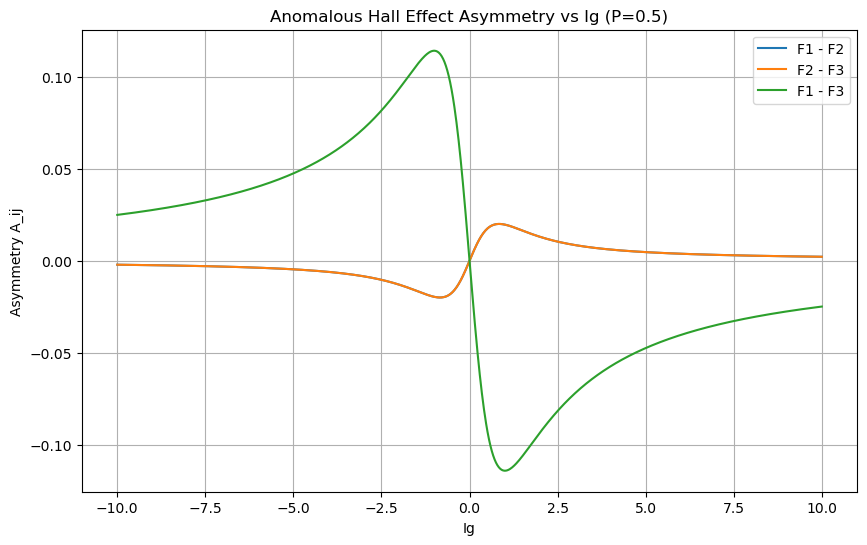

In [32]:
import numpy as np
import matplotlib.pyplot as plt
def compute_AHE(P_val):
    #Reset entire build
    global Setup
    from spintronics import SpintronicCircuit
    Setup = SpintronicCircuit()
    setup0()
    Setup.finalize()

        #setting magnetization of the nodes
    Setup.setMagnetization('F1', 'T', [-1.0,0,0])
    Setup.setMagnetization('F2', 'T', [0,-1.0,0])
    Setup.setMagnetization('F3', 'T', [0,0,-1.0])

    G = 1.0
    Ig_values = np.linspace(-10,10,1000)
    # First setup magnetizations
    A_12, A_23, A_13 = [], [], []
    for Ig in Ig_values:
        pars = [G, P_val, 0.0, Ig]
        Setup.setConductance('CF1',pars)
        Setup.setConductance('CF2',pars)
        Setup.setConductance('CF3',pars)

        Setup.compute()
        G_mat = Setup.ConductanceMatrix

        #Assymetries
        a12 = (G_mat[2,3] - G_mat[3,2]) / (G_mat[2,3] + G_mat[3,2])
        a23 = (G_mat[3,4] - G_mat[4,3]) / (G_mat[3,4] + G_mat[4,3])
        a13 = (G_mat[2,4] - G_mat[4,2]) / (G_mat[2,4] + G_mat[4,2])

        A_12.append(a12)
        A_23.append(a23)
        A_13.append(a13)
    return Ig_values, np.array(A_12), np.array(A_23), np.array(A_13)

Ig_vals, A12, A23, A13 = compute_AHE(P_val=0.5)
# Plotting
plt.figure(figsize=(10, 6))
plt.plot(Ig_vals, A12, label='F1 - F2')
plt.plot(Ig_vals, A23, label='F2 - F3')
plt.plot(Ig_vals, A13, label='F1 - F3')
plt.xlabel('Ig')
plt.ylabel('Asymmetry A_ij')
plt.title('Anomalous Hall Effect Asymmetry vs Ig (P=0.5)')
plt.legend()
plt.grid(True)
plt.savefig("graph_b1", dpi=300)
plt.show()



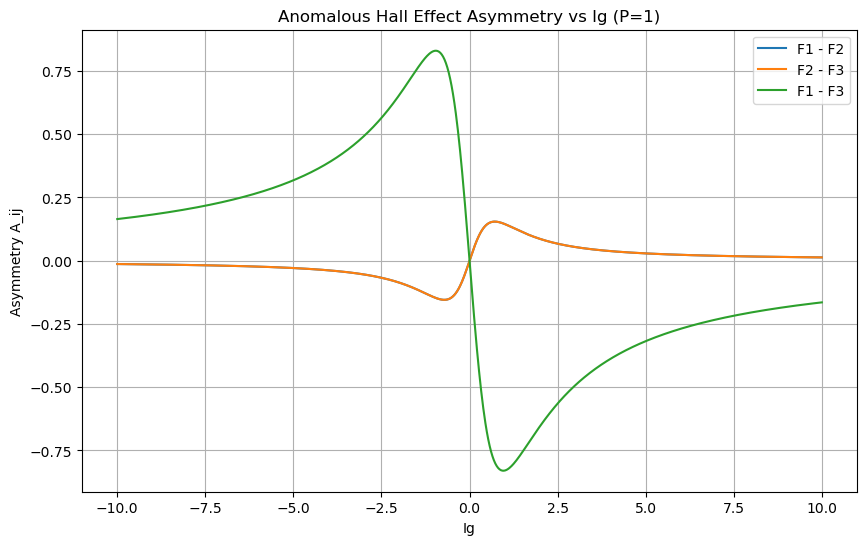

In [33]:
Ig_vals, A12, A23, A13 = compute_AHE(P_val=1.0)
# Plotting
plt.figure(figsize=(10, 6))
plt.plot(Ig_vals, A12, label='F1 - F2')
plt.plot(Ig_vals, A23, label='F2 - F3')
plt.plot(Ig_vals, A13, label='F1 - F3')
plt.xlabel('Ig')
plt.ylabel('Asymmetry A_ij')
plt.title('Anomalous Hall Effect Asymmetry vs Ig (P=1)')
plt.legend()
plt.grid(True)
plt.savefig("graph_b2", dpi=300)
plt.show()

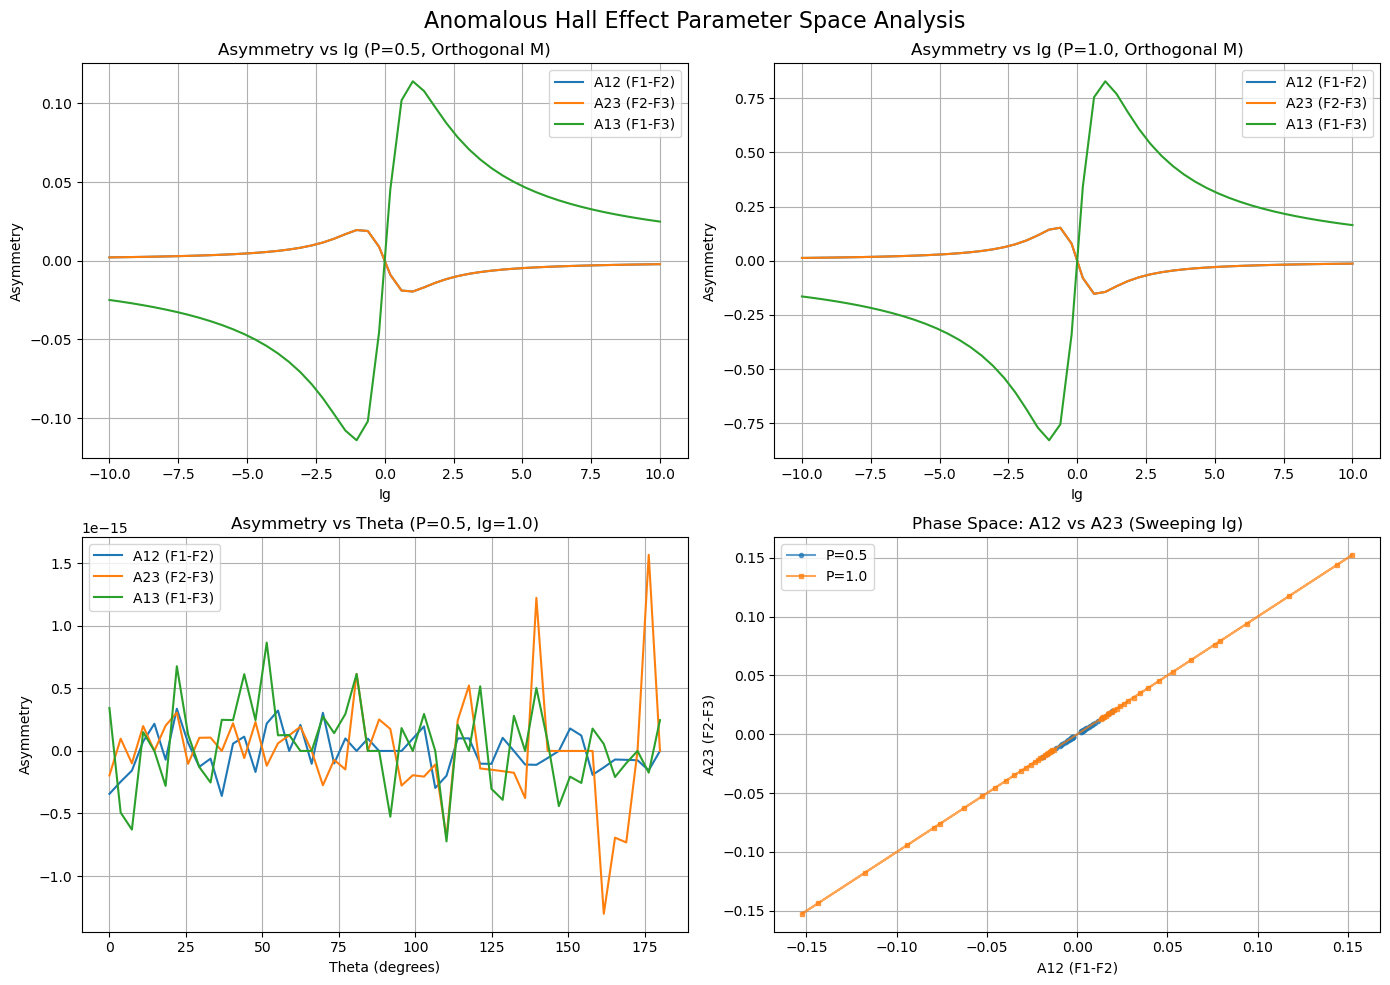

In [34]:
import numpy as np
import matplotlib.pyplot as plt

def compute_asymmetry(G_mat):
    """Helper function to safely compute the AHE asymmetry matrix."""
    # A_ij = (G_ij - G_ji) / (G_ij + G_ji)
    A = np.zeros((5,5))
    for i in range(5):
        for j in range(5):
            denom = G_mat[i,j] + G_mat[j,i]
            if denom != 0:
                A[i,j] = (G_mat[i,j] - G_mat[j,i]) / denom
    # Return specific terminal pairs: F1-F2 (2,3), F2-F3 (3,4), F1-F3 (2,4)
    return A[2,3], A[3,4], A[2,4]

def generate_parameter_plots():
    global Setup
    from spintronics import SpintronicCircuit
    Setup = SpintronicCircuit()
    Setup.addNormalTerminal("Left")
    Setup.addNormalTerminal("Right")
    Setup.addFerroTerminal("F1", magnetization=[1.0, 0, 0])
    Setup.addFerroTerminal("F2", magnetization=[0, 1.0, 0])
    Setup.addFerroTerminal("F3", magnetization=[0, 0, 1.0])
    Setup.addNormalNode("N1")
    Setup.addNormalNode("N2")
    Setup.addNormalNode("N3")
    Gn = 1.0
    GFN = [1.0, 0.5, 0.0, 0.0]
    Setup.addConductor("C0", 'NT', 'N1', 'Left', Gn)
    Setup.addConductor("C3", 'NT', 'N3', 'Right', Gn)
    Setup.addConductor("C1", 'NN', 'N1', 'N2', Gn)
    Setup.addConductor("C2", 'NN', 'N2', 'N3', Gn)
    Setup.addConductor('CF1', 'NT', 'N1', 'F1', GFN)
    Setup.addConductor('CF2', 'NT', 'N2', 'F2', GFN)
    Setup.addConductor('CF3', 'NT', 'N3', 'F3', GFN)
    Setup.finalize()

    # Define our sweep arrays
    Ig_array = np.linspace(-10, 10, 50)
    theta_array = np.linspace(0, np.pi, 50)

    # Prepare the figure grid
    fig, axs = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle('Anomalous Hall Effect Parameter Space Analysis', fontsize=16)

    # PLOT 1: Asymmetry vs Ig for P = 0.5
    Setup.setMagnetization('F1', 'T', [1, 0, 0])
    Setup.setMagnetization('F2', 'T', [0, 1, 0])
    Setup.setMagnetization('F3', 'T', [0, 0, 1])

    A12_list, A23_list, A13_list = [], [], []
    for ig in Ig_array:
        Setup.setConductance('CF1', [1.0, 0.5, 0.0, ig])
        Setup.setConductance('CF2', [1.0, 0.5, 0.0, ig])
        Setup.setConductance('CF3', [1.0, 0.5, 0.0, ig])
        Setup.compute()
        a12, a23, a13 = compute_asymmetry(Setup.ConductanceMatrix)
        A12_list.append(a12)
        A23_list.append(a23)
        A13_list.append(a13)

    axs[0, 0].plot(Ig_array, A12_list, label='A12 (F1-F2)')
    axs[0, 0].plot(Ig_array, A23_list, label='A23 (F2-F3)')
    axs[0, 0].plot(Ig_array, A13_list, label='A13 (F1-F3)')
    axs[0, 0].set_title('Asymmetry vs Ig (P=0.5, Orthogonal M)')
    axs[0, 0].set_xlabel('Ig')
    axs[0, 0].set_ylabel('Asymmetry')
    axs[0, 0].legend()
    axs[0, 0].grid(True)

    # PLOT 2: Asymmetry vs Ig for P = 1.0 (same magnetizations, already set)
    A12_list_P1, A23_list_P1, A13_list_P1 = [], [], []
    for ig in Ig_array:
        Setup.setConductance('CF1', [1.0, 1.0, 0.0, ig])
        Setup.setConductance('CF2', [1.0, 1.0, 0.0, ig])
        Setup.setConductance('CF3', [1.0, 1.0, 0.0, ig])
        Setup.compute()
        a12, a23, a13 = compute_asymmetry(Setup.ConductanceMatrix)
        A12_list_P1.append(a12)
        A23_list_P1.append(a23)
        A13_list_P1.append(a13)

    axs[0, 1].plot(Ig_array, A12_list_P1, label='A12 (F1-F2)')
    axs[0, 1].plot(Ig_array, A23_list_P1, label='A23 (F2-F3)')
    axs[0, 1].plot(Ig_array, A13_list_P1, label='A13 (F1-F3)')
    axs[0, 1].set_title('Asymmetry vs Ig (P=1.0, Orthogonal M)')
    axs[0, 1].set_xlabel('Ig')
    axs[0, 1].set_ylabel('Asymmetry')
    axs[0, 1].legend()
    axs[0, 1].grid(True)

    # PLOT 3: Asymmetry vs Theta for P=0.5, Ig=1.0
    Setup.setMagnetization('F1', 'T', [1, 0, 0])   # fixed along x
    Setup.setMagnetization('F3', 'T', [0, 0, 1])   # fixed along z
    A12_theta, A23_theta, A13_theta = [], [], []

    for th in theta_array:
        M2 = [np.sin(th), 0, np.cos(th)]           # sweeps in xz-plane
        Setup.setMagnetization('F2', 'T', M2)
        Setup.compute()

        a12, a23, a13 = compute_asymmetry(Setup.ConductanceMatrix)
        A12_theta.append(a12)
        A23_theta.append(a23)
        A13_theta.append(a13)

    axs[1, 0].plot(np.degrees(theta_array), A12_theta, label='A12 (F1-F2)')
    axs[1, 0].plot(np.degrees(theta_array), A23_theta, label='A23 (F2-F3)')
    axs[1, 0].plot(np.degrees(theta_array), A13_theta, label='A13 (F1-F3)')
    axs[1, 0].set_title('Asymmetry vs Theta (P=0.5, Ig=1.0)')
    axs[1, 0].set_xlabel('Theta (degrees)')
    axs[1, 0].set_ylabel('Asymmetry')
    axs[1, 0].legend()
    axs[1, 0].grid(True)

    # PLOT 4: Phase space A12 vs A23 for both P values
    axs[1, 1].plot(A12_list, A23_list, marker='o', markersize=3,
                   linestyle='-', alpha=0.7, label='P=0.5')
    axs[1, 1].plot(A12_list_P1, A23_list_P1, marker='s', markersize=3,
                   linestyle='-', alpha=0.7, label='P=1.0')
    axs[1, 1].set_title('Phase Space: A12 vs A23 (Sweeping Ig)')
    axs[1, 1].set_xlabel('A12 (F1-F2)')
    axs[1, 1].set_ylabel('A23 (F2-F3)')
    axs[1, 1].legend()
    axs[1, 1].grid(True)

    plt.tight_layout()
    plt.savefig("graph_b", dpi=300)
    plt.show()



generate_parameter_plots()

In [35]:
from scipy.optimize import minimize

def optimize_asymmetry():
    """Maximize |A13| (largest asymmetry pair) over GF and Ig, P=0.5, G=1, Rg=0."""
    global Setup
    from spintronics import SpintronicCircuit
    Setup = SpintronicCircuit()
    Setup.addNormalTerminal("Left")
    Setup.addNormalTerminal("Right")
    Setup.addFerroTerminal("F1", magnetization=[1.0, 0, 0])
    Setup.addFerroTerminal("F2", magnetization=[0, 1.0, 0])
    Setup.addFerroTerminal("F3", magnetization=[0, 0, 1.0])
    Setup.addNormalNode("N1")
    Setup.addNormalNode("N2")
    Setup.addNormalNode("N3")
    Gn = 1.0
    GFN = [1.0, 0.5, 0.0, 0.0]
    Setup.addConductor("C0", 'NT', 'N1', 'Left', Gn)
    Setup.addConductor("C3", 'NT', 'N3', 'Right', Gn)
    Setup.addConductor("C1", 'NN', 'N1', 'N2', Gn)
    Setup.addConductor("C2", 'NN', 'N2', 'N3', Gn)
    Setup.addConductor('CF1', 'NT', 'N1', 'F1', GFN)
    Setup.addConductor('CF2', 'NT', 'N2', 'F2', GFN)
    Setup.addConductor('CF3', 'NT', 'N3', 'F3', GFN)
    Setup.finalize()

    Setup.setMagnetization('F1', 'T', [1, 0, 0])
    Setup.setMagnetization('F2', 'T', [0, 1, 0])
    Setup.setMagnetization('F3', 'T', [0, 0, 1])

    def neg_abs_A13(params):
        GF, Ig = params
        if GF <= 0:
            return 0.0
        Setup.setConductance('CF1', [1.0, 0.5, 0.0, Ig])
        Setup.setConductance('CF2', [1.0, 0.5, 0.0, Ig])
        Setup.setConductance('CF3', [1.0, 0.5, 0.0, Ig])
        Setup.compute()
        G_mat = Setup.ConductanceMatrix
        denom = G_mat[2,4] + G_mat[4,2]
        if denom == 0:
            return 0.0
        return -abs((G_mat[2,4] - G_mat[4,2]) / denom)

    def neg_abs_A12(params):
        GF, Ig = params
        if GF <= 0:
            return 0.0
        Setup.setConductance('CF1', [1.0, 0.5, 0.0, Ig])
        Setup.setConductance('CF2', [1.0, 0.5, 0.0, Ig])
        Setup.setConductance('CF3', [1.0, 0.5, 0.0, Ig])
        Setup.compute()
        G_mat = Setup.ConductanceMatrix
        denom = G_mat[2,3] + G_mat[3,2]
        if denom == 0:
            return 0.0
        return -abs((G_mat[2,3] - G_mat[3,2]) / denom)

    bounds = [(0.01, 10.0), (-20.0, 20.0)]

    best_A13, best_params_A13 = 0, None
    best_A12, best_params_A12 = 0, None

    for _ in range(20):
        x0 = [np.random.uniform(0.1, 5), np.random.uniform(-10, 10)]

        res13 = minimize(neg_abs_A13, x0, method='L-BFGS-B', bounds=bounds)
        if -res13.fun > best_A13:
            best_A13 = -res13.fun
            best_params_A13 = res13.x

        res12 = minimize(neg_abs_A12, x0, method='L-BFGS-B', bounds=bounds)
        if -res12.fun > best_A12:
            best_A12 = -res12.fun
            best_params_A12 = res12.x

    print(f"Maximum |A13| (F1-F3): {best_A13:.4f} at GF={best_params_A13[0]:.4f}, Ig={best_params_A13[1]:.4f}")
    print(f"Maximum |A12| (F1-F2): {best_A12:.4f} at GF={best_params_A12[0]:.4f}, Ig={best_params_A12[1]:.4f}")

optimize_asymmetry()


Maximum |A13| (F1-F3): 0.1141 at GF=1.5125, Ig=1.0040
Maximum |A12| (F1-F2): 0.0200 at GF=4.4055, Ig=0.8390


### Exercise 4c - Magnetic dependence

In [36]:
def setup_topology():
    # First the Normal terminals
    global Setup
    from spintronics import SpintronicCircuit
    Setup = SpintronicCircuit()
    Setup.addNormalTerminal("Left")
    Setup.addNormalTerminal("Right")

    # Adding ferro terminals
    Setup.addFerroTerminal("F1",magnetization=M1)
    Setup.addFerroTerminal("F2",magnetization=M2)
    Setup.addFerroTerminal("F3",magnetization=M3)

    # Add the normal nodes, no Ferromagnetic elements yet.
    Setup.addNormalNode("N1")
    Setup.addNormalNode("N2")
    Setup.addNormalNode("N3")


    #Define the params
    Gf = 0.5
    P = 1.0
    Rg = 0
    Ig = 1.0
    Gn = 1.0 #For normal connectors
    GFN=[Gf,P,Rg,Ig]
    # Now the normal connectors, treated as Ohmic conductors
    Setup.addConductor("C0", 'NT', 'N1', 'Left', Gn)
    Setup.addConductor("C3", 'NT', 'N3', 'Right', Gn)
    Setup.addConductor("C1", 'NN', 'N1', 'N2', Gn)
    Setup.addConductor("C2", 'NN', 'N2', 'N3', Gn)

    # The F-N connectors
    Setup.addConductor('CF1', 'NT', 'N1', 'F1', GFN)
    Setup.addConductor('CF2', 'NT', 'N2', 'F2', GFN)
    Setup.addConductor('CF3', 'NT', 'N3', 'F3', GFN)

    Setup.finalize()

#Randomly chosen params below
phi  = 0
psi = np.pi /2
theta  = np.pi /4
M1 = [np.sin(phi/2), 0, np.cos(phi/2)]
M2 = [np.sin(psi)*np.sin(theta), np.cos(psi)*np.sin(theta), np.cos(theta)]
M3 = [-np.sin(phi/2), 0, np.cos(phi/2)]

# Setting up topology
setup_topology()
#Setting the magnetization
Setup.setMagnetization('F1', 'T', M1)
Setup.setMagnetization('F2', 'T', M2)
Setup.setMagnetization('F3', 'T', M3)

Setup.compute()

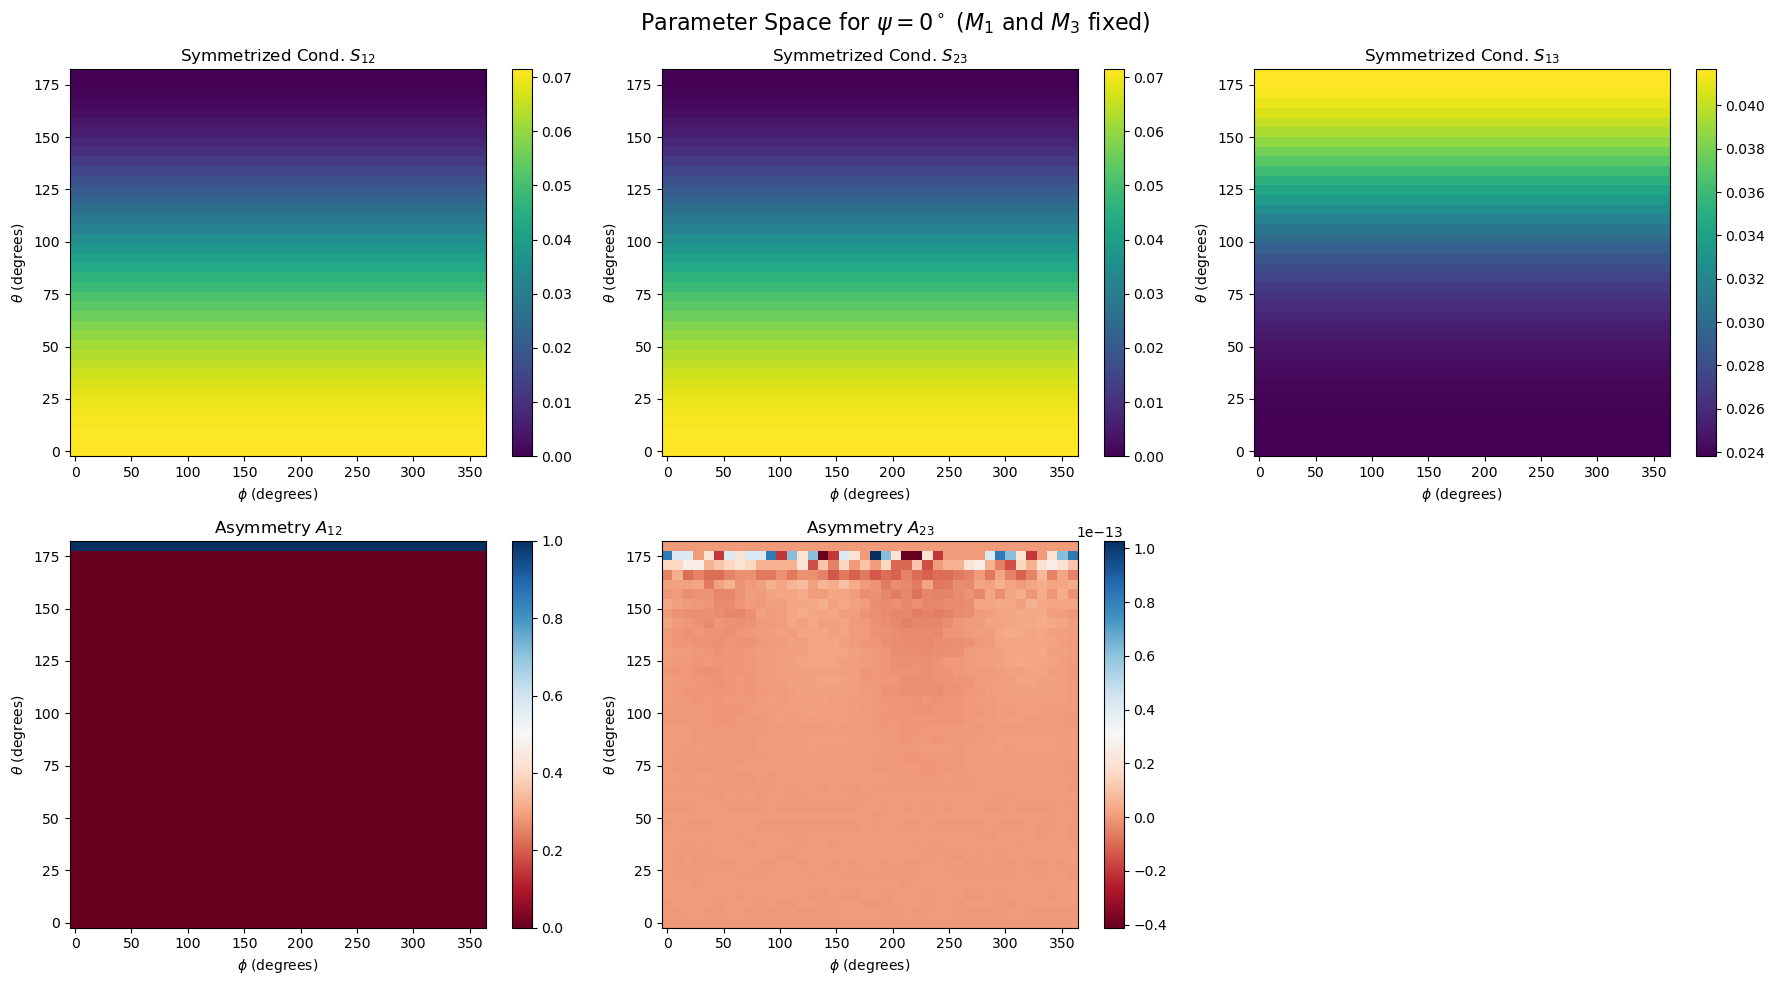

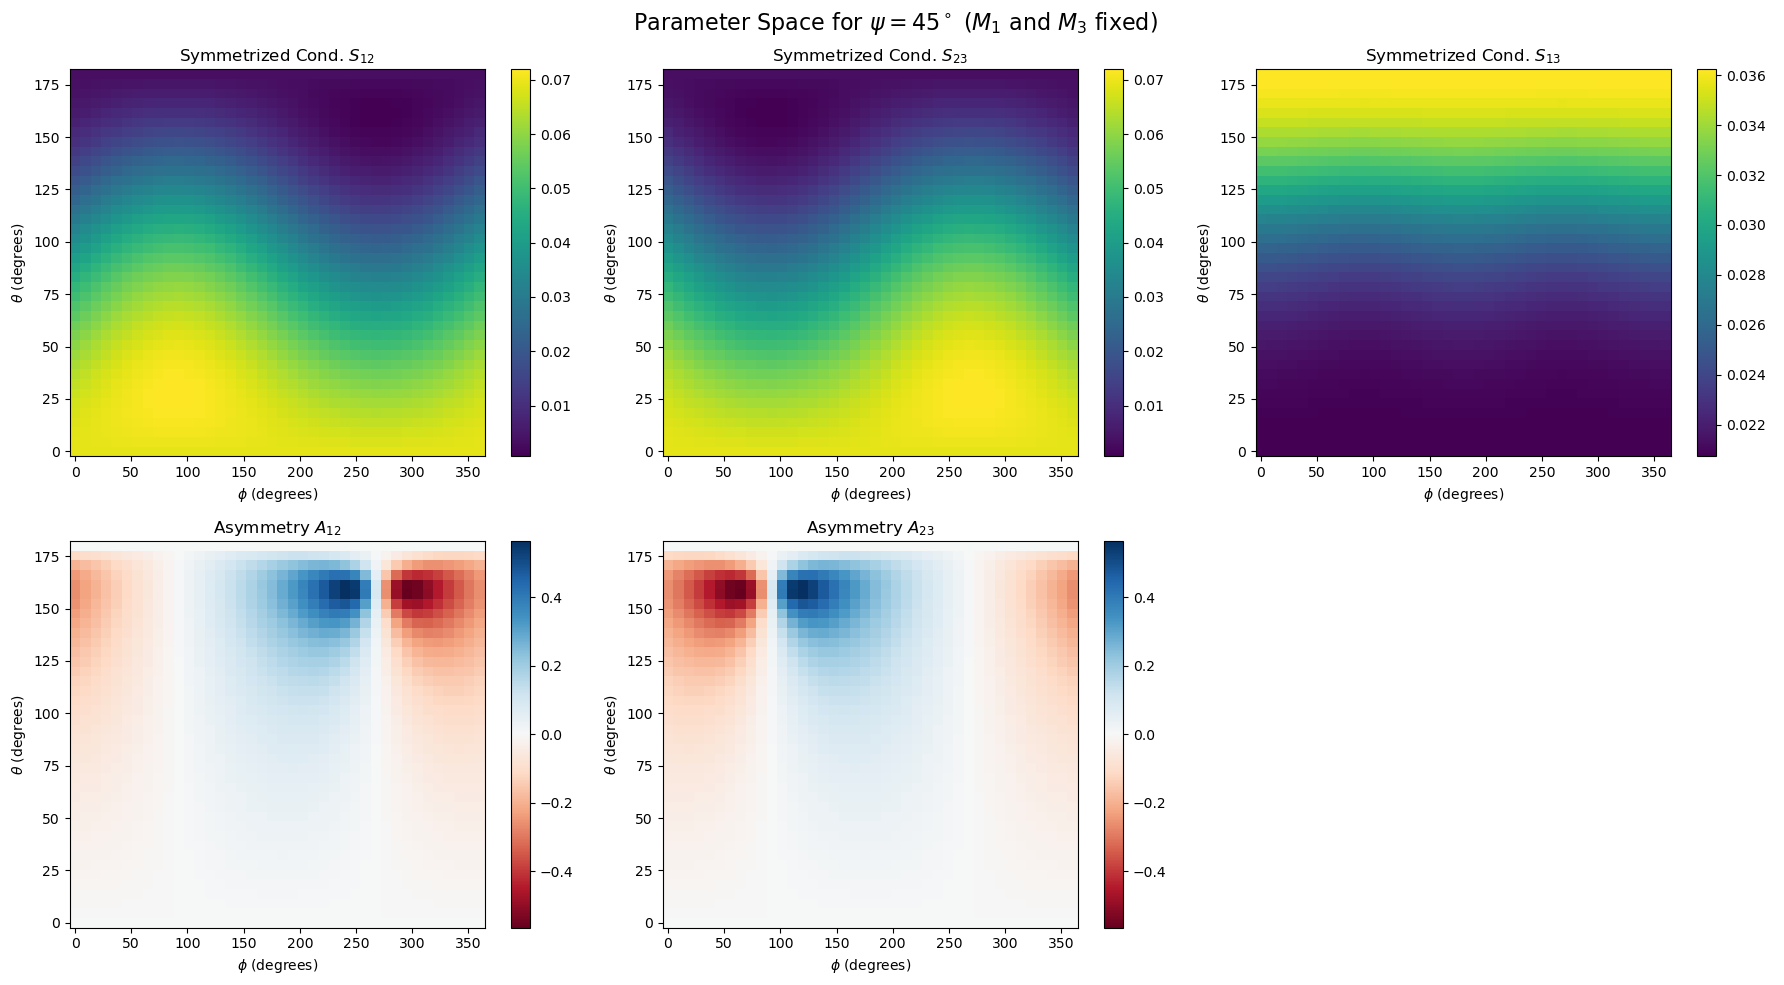

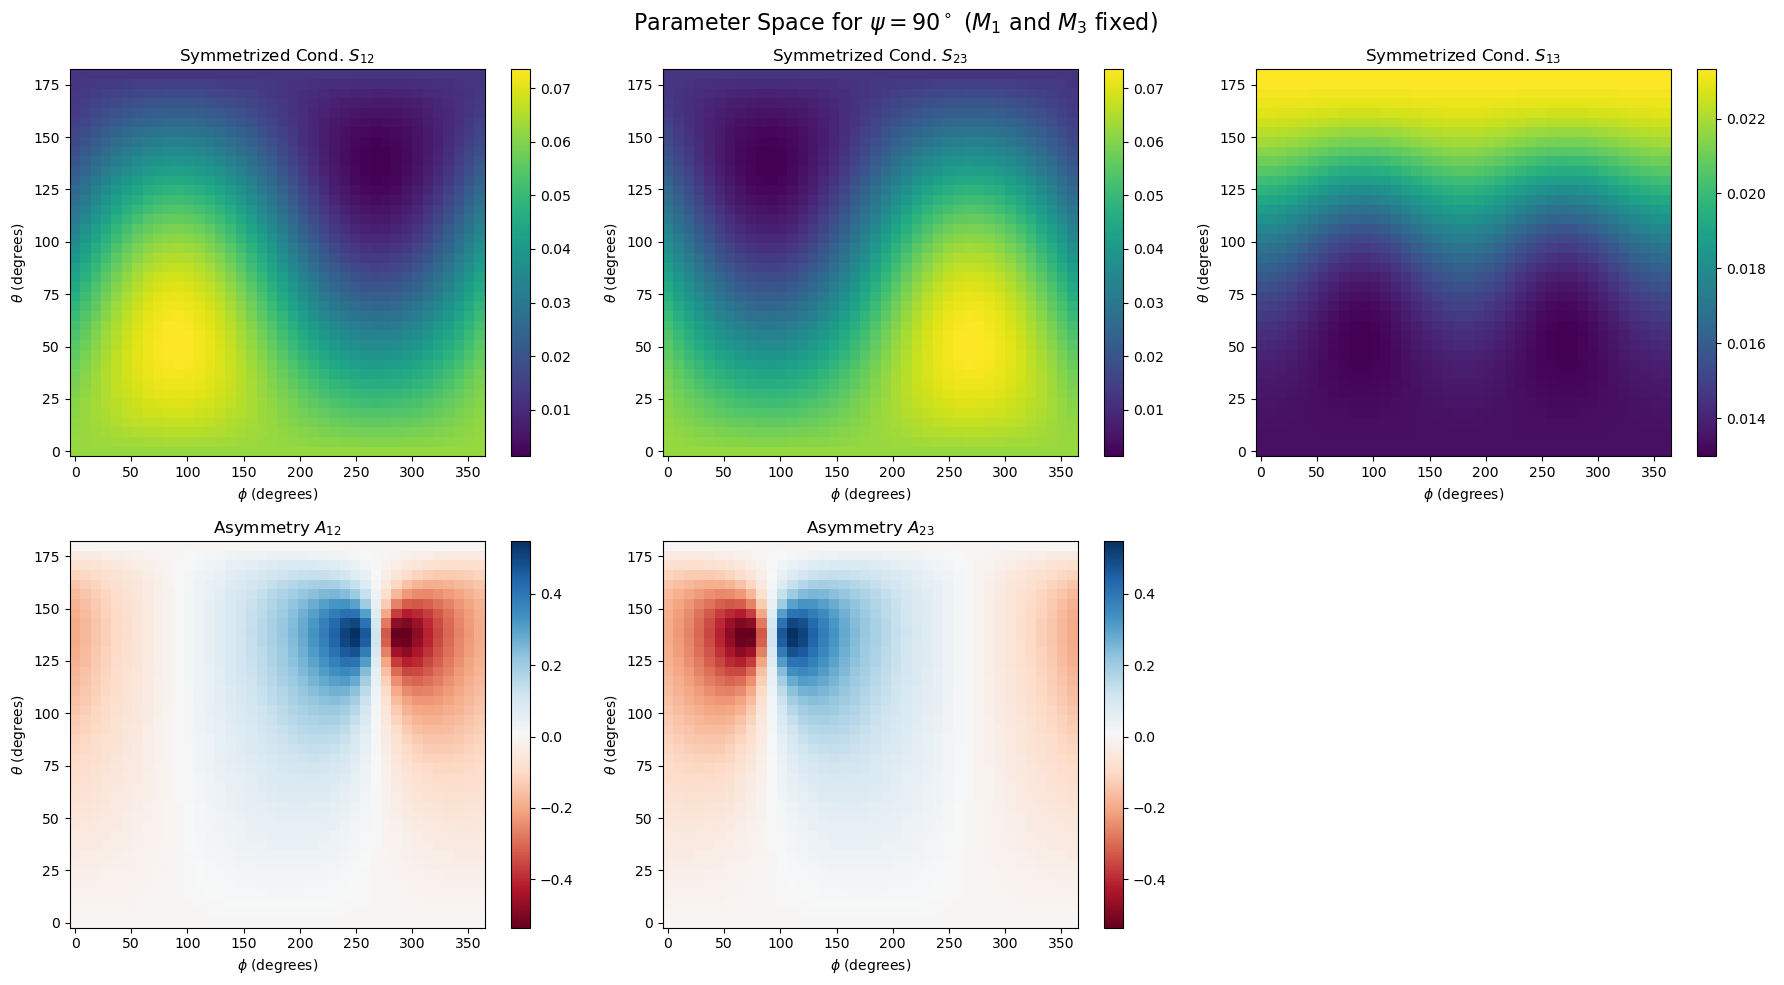

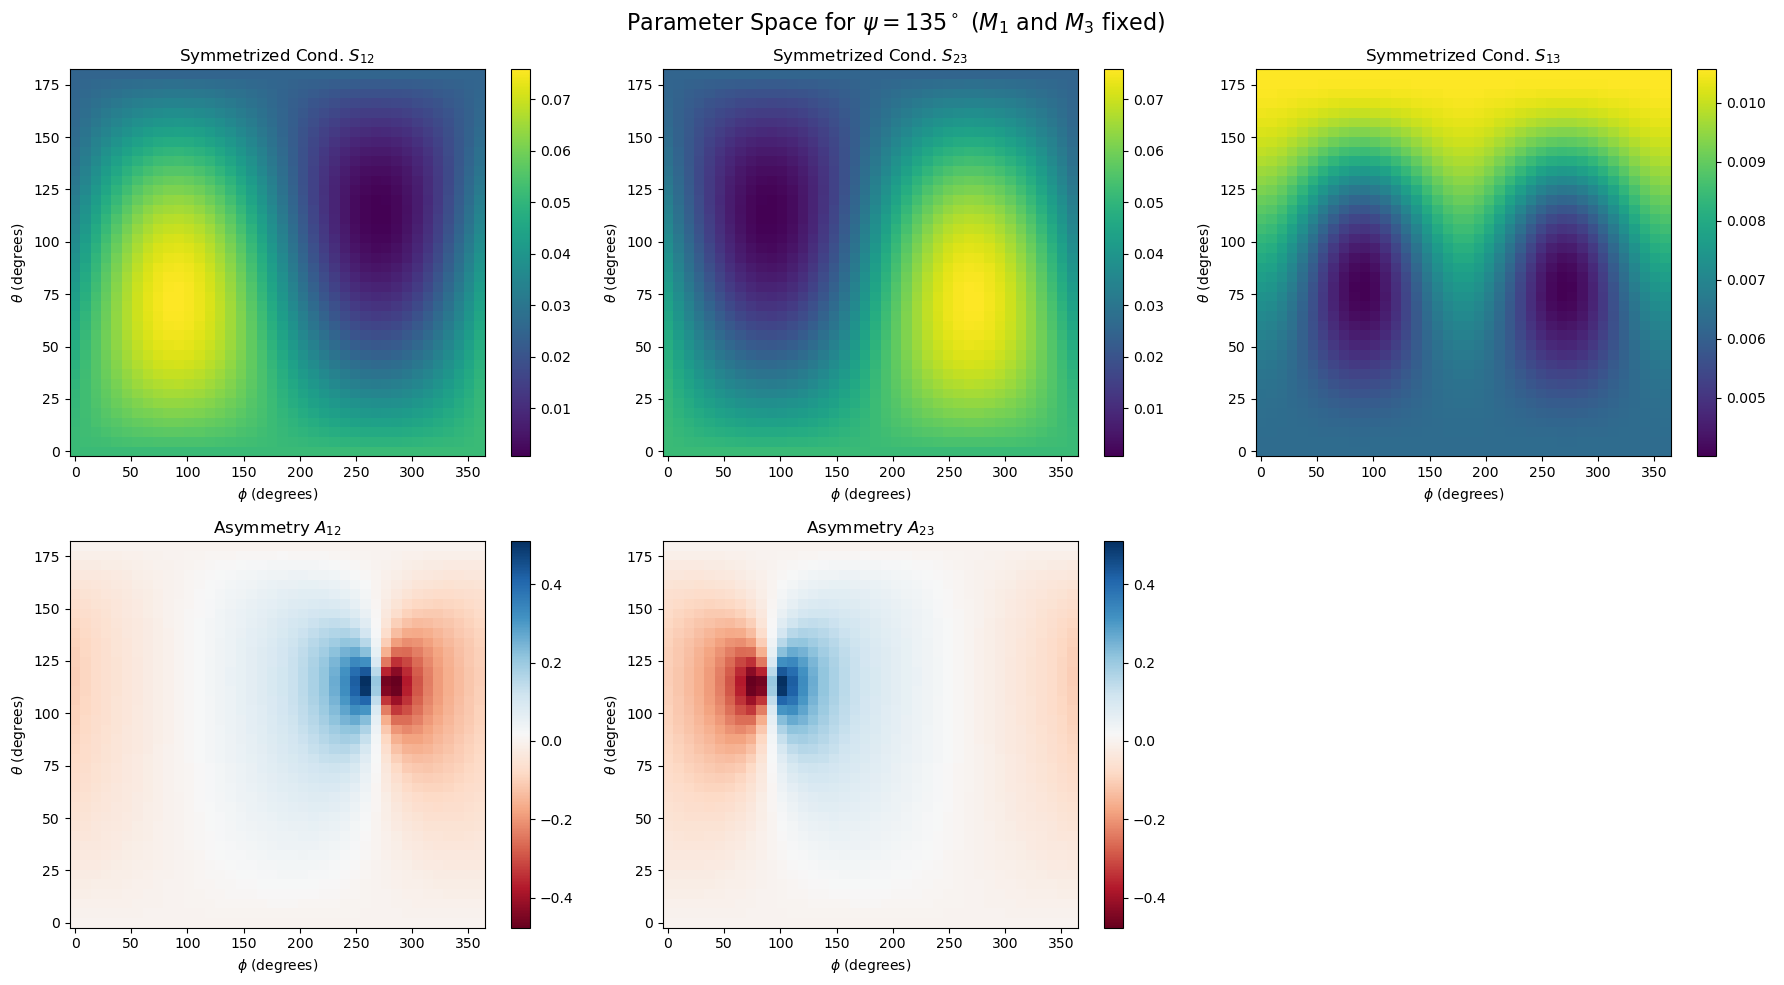

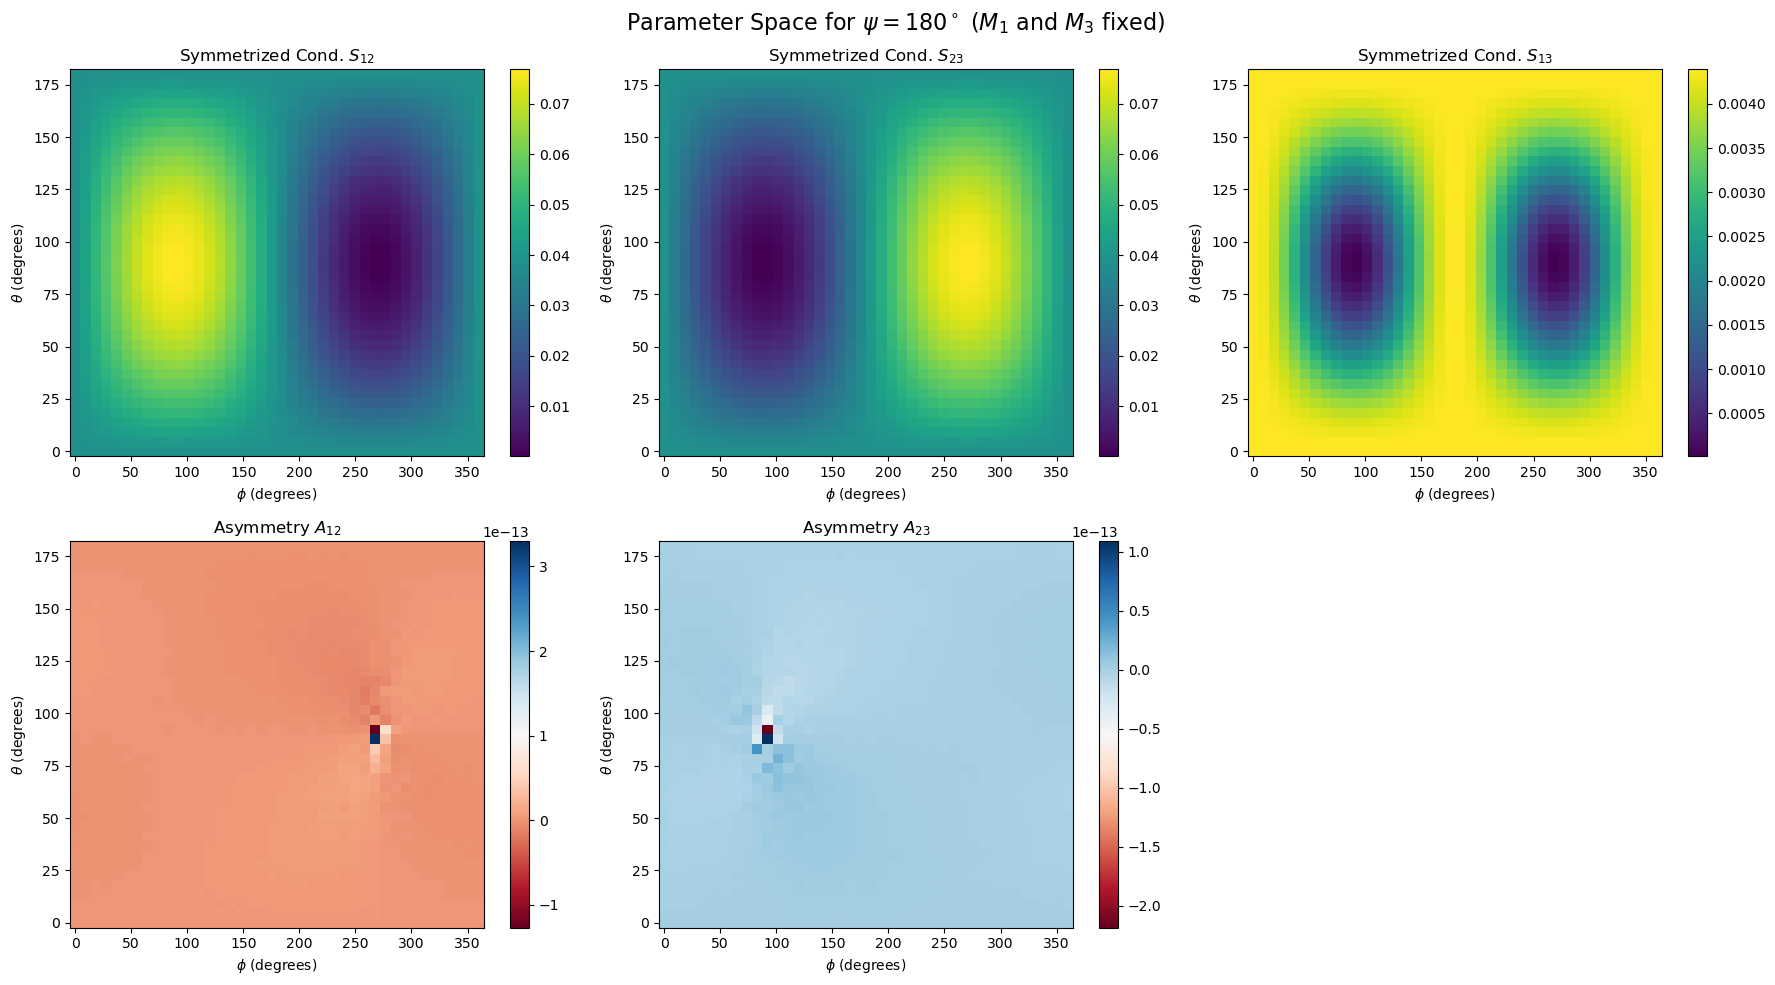

In [37]:
def generate_3param_colormaps(psi_deg):
    """
    Generates color maps for symmetrized conductances and asymmetries
    by sweeping phi and theta for a fixed psi.
    """
    # Params
    Gf = 0.5
    P = 1.0
    Rg = 0.0
    Ig = 1.0
    GFN = [Gf, P, Rg, Ig]

    # Inject parameters
    Setup.setConductance('CF1', GFN)
    Setup.setConductance('CF2', GFN)
    Setup.setConductance('CF3', GFN)

    # Setup the sweep grids
    resolution = 40  # Increase to 60 or 80 for smoother plots, 40 is fast.
    phi_vals = np.linspace(0, 2 * np.pi, resolution)
    theta_vals = np.linspace(0, np.pi, resolution)

    # Create empty grids to store our data
    S12_grid = np.zeros((resolution, resolution))
    S23_grid = np.zeros((resolution, resolution))
    S13_grid = np.zeros((resolution, resolution))

    A12_grid = np.zeros((resolution, resolution))
    A23_grid = np.zeros((resolution, resolution))

    psi = np.radians(psi_deg)

    M1 = [np.sin(psi/2), 0, np.cos(psi/2)]
    M3 = [-np.sin(psi/2), 0, np.cos(psi/2)]
    Setup.setMagnetization('F1', 'T', M1)
    Setup.setMagnetization('F3', 'T', M3)

    # Loop for M2
    for i, theta in enumerate(theta_vals):
        for j, phi in enumerate(phi_vals):
            M2 = [np.sin(phi)*np.sin(theta), np.cos(phi)*np.sin(theta), np.cos(theta)]
            Setup.setMagnetization('F2', 'T', M2)

            Setup.compute()
            G_mat = Setup.ConductanceMatrix

            S12_grid[i, j] = (G_mat[2,3] + G_mat[3,2]) / 2.0
            S23_grid[i, j] = (G_mat[3,4] + G_mat[4,3]) / 2.0
            S13_grid[i, j] = (G_mat[2,4] + G_mat[4,2]) / 2.0

            # Asymmetries: A = (G_ij - G_ji) / (G_ij + G_ji)
            denom12 = G_mat[2,3] + G_mat[3,2]
            denom23 = G_mat[3,4] + G_mat[4,3]

            A12_grid[i, j] = (G_mat[2,3] - G_mat[3,2]) / denom12 if denom12 != 0 else 0
            A23_grid[i, j] = (G_mat[3,4] - G_mat[4,3]) / denom23 if denom23 != 0 else 0

    # Plotting the grids
    Phi_mesh, Theta_mesh = np.meshgrid(np.degrees(phi_vals), np.degrees(theta_vals))

    fig, axs = plt.subplots(2, 3, figsize=(18, 10))
    fig.suptitle(f'Parameter Space for $\psi = {psi_deg}^\circ$ ($M_1$ and $M_3$ fixed)', fontsize=16)

    # Helper for repetitive pcolormesh calls
    def plot_map(ax, data, title, cmap_name):
        c = ax.pcolormesh(Phi_mesh, Theta_mesh, data, shading='auto', cmap=cmap_name)
        ax.set_title(title)
        ax.set_xlabel('$\phi$ (degrees)')
        ax.set_ylabel('$\\theta$ (degrees)')
        fig.colorbar(c, ax=ax)

    # Top Row: Symmetrized Conductances
    plot_map(axs[0, 0], S12_grid, 'Symmetrized Cond. $S_{12}$', 'viridis')
    plot_map(axs[0, 1], S23_grid, 'Symmetrized Cond. $S_{23}$', 'viridis')
    plot_map(axs[0, 2], S13_grid, 'Symmetrized Cond. $S_{13}$', 'viridis')

    # Bottom Row: Asymmetries
    plot_map(axs[1, 0], A12_grid, 'Asymmetry $A_{12}$', 'RdBu')
    plot_map(axs[1, 1], A23_grid, 'Asymmetry $A_{23}$', 'RdBu')
    axs[1, 2].axis('off')

    plt.tight_layout()
    plt.savefig(f"conductance_map_psi_{psi_deg}deg.png", dpi=300)
    plt.show()

# Loop through standard degree targets
for psi_deg in [0, 45, 90, 135, 180]:
    generate_3param_colormaps(psi_deg=psi_deg)

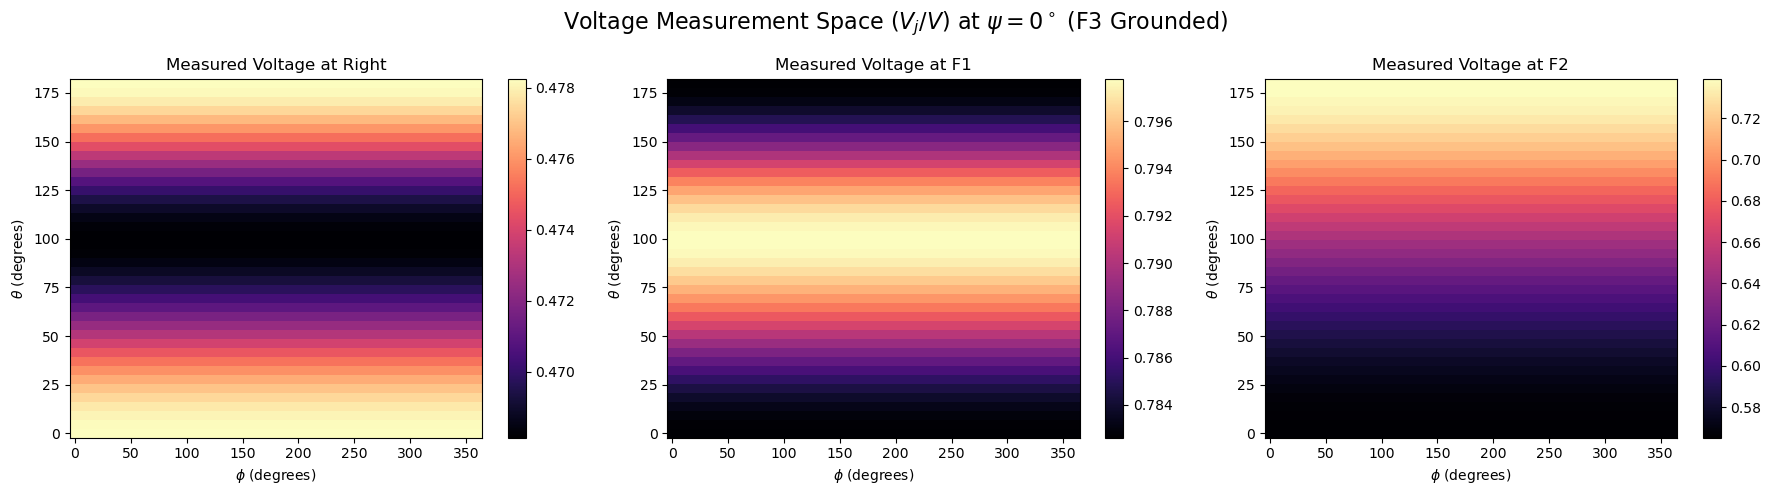

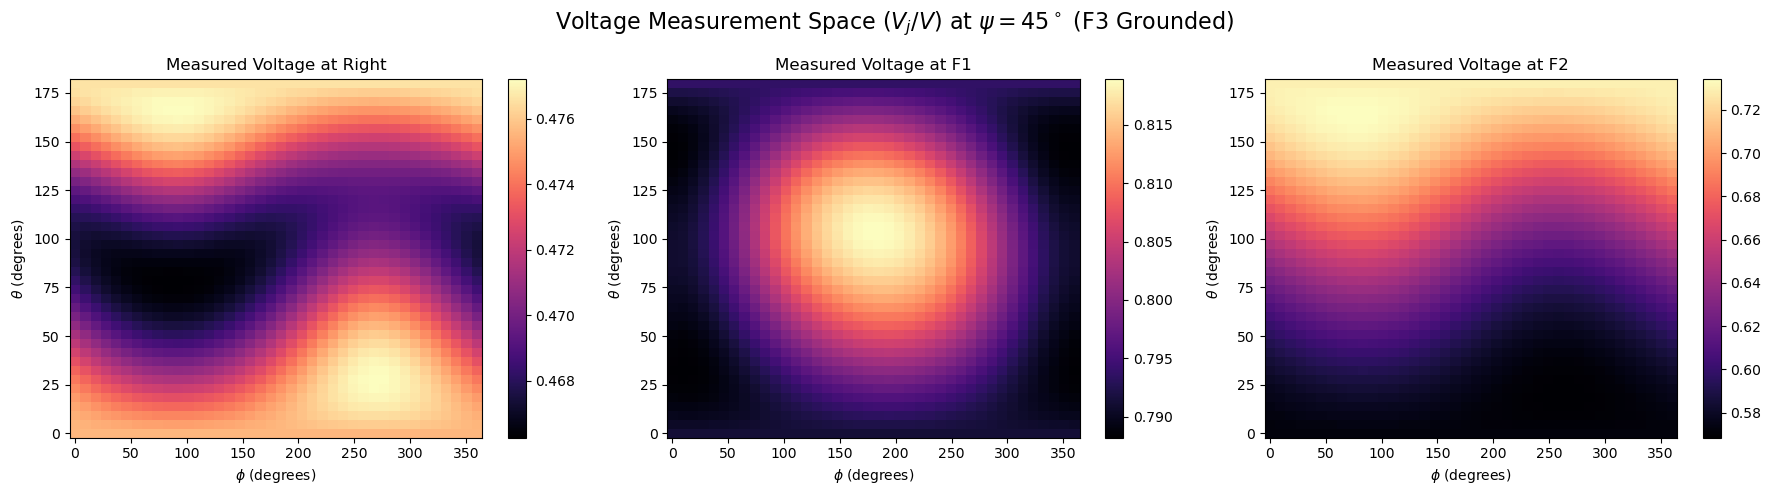

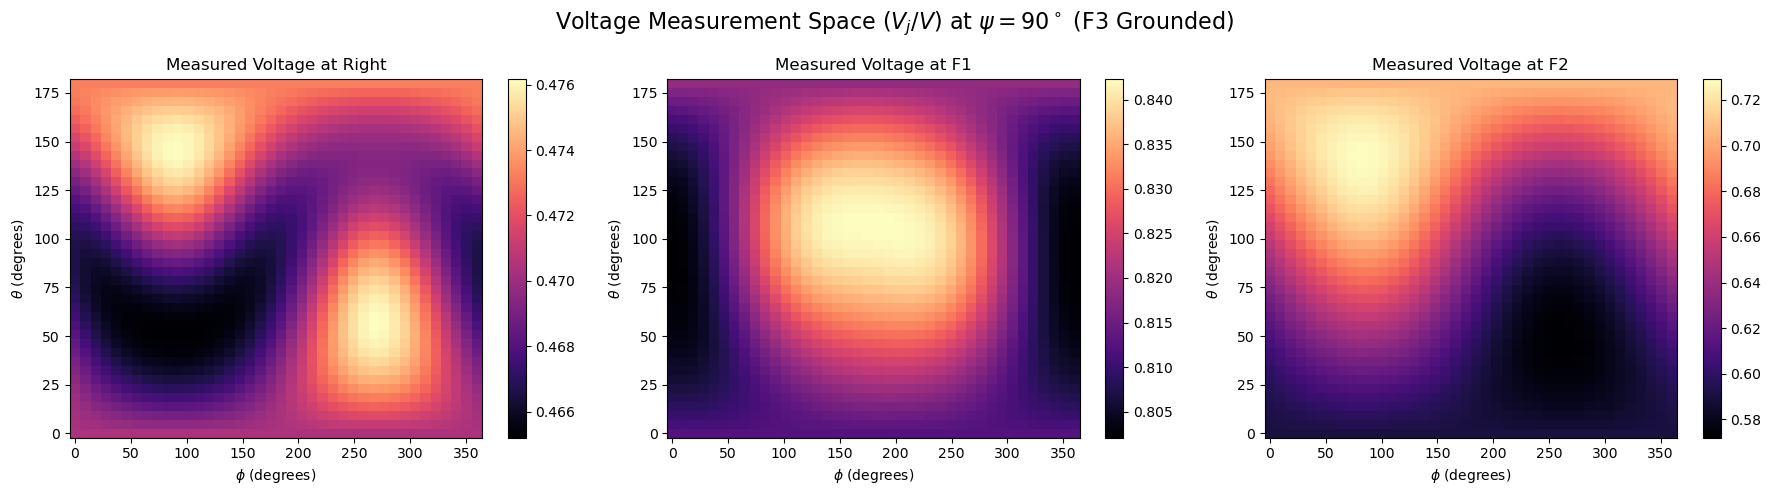

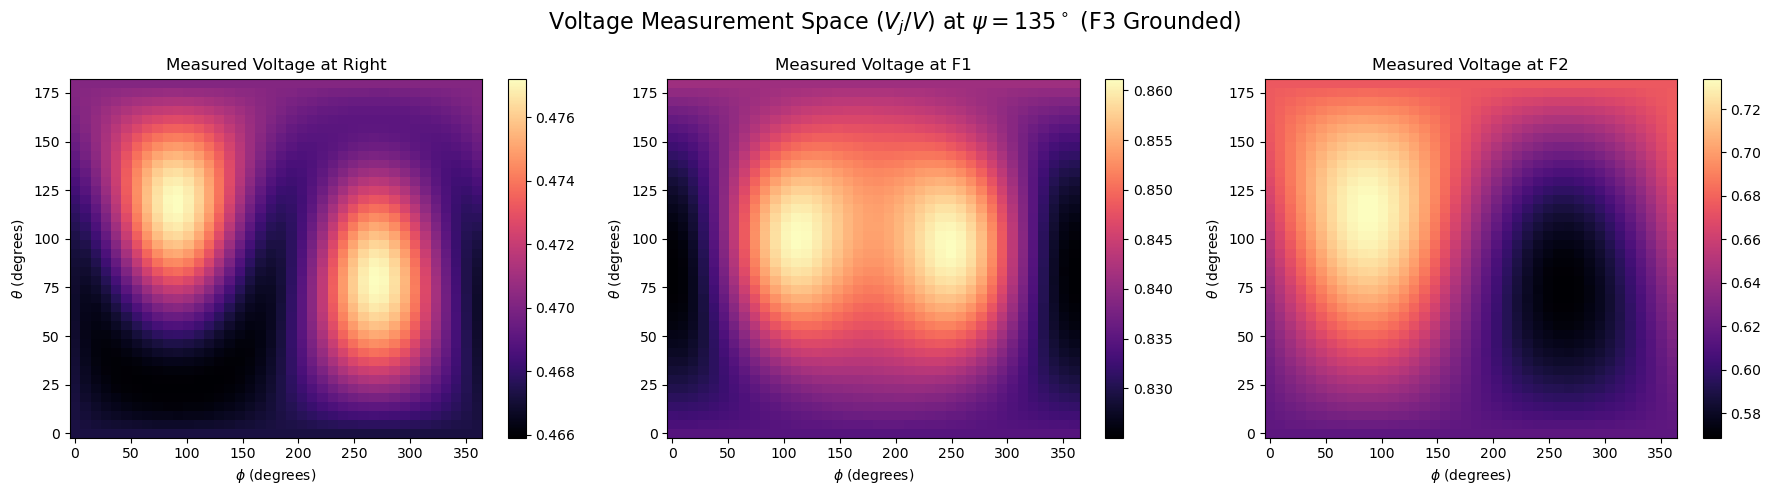

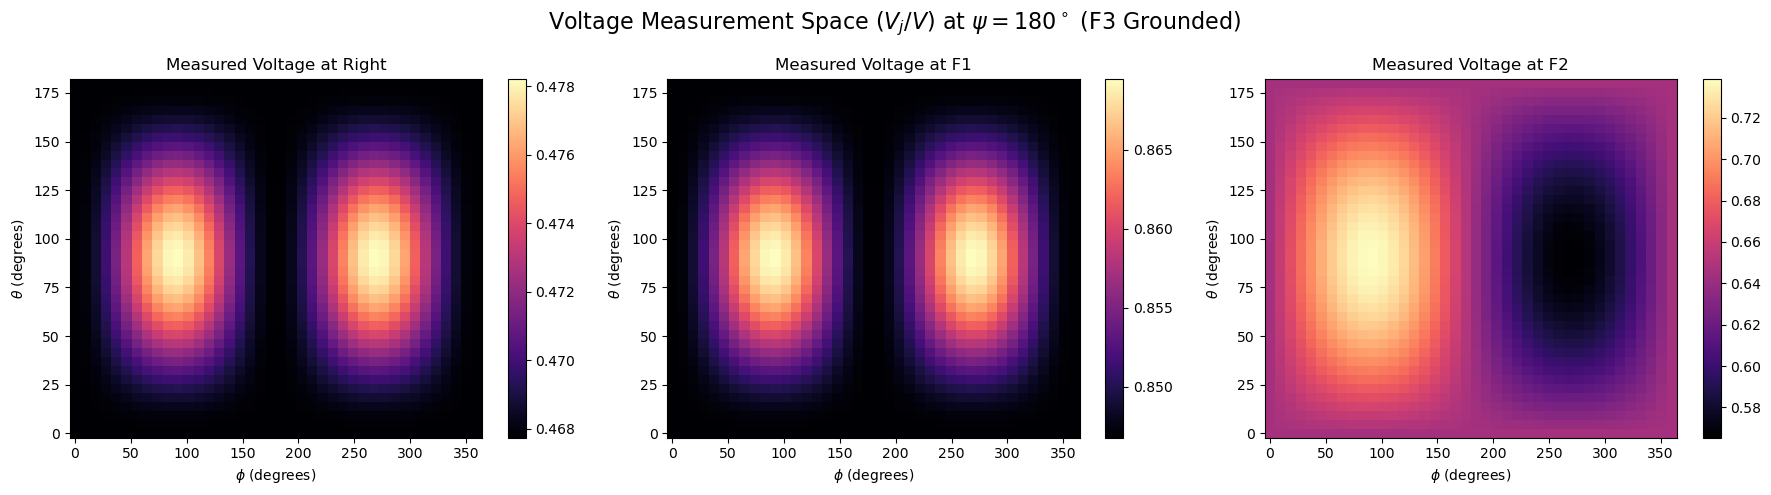

In [38]:
#Imports
import matplotlib.pyplot as plt

# Define Circuit Topology
def build_clean_topology():
    """Initializes, builds, and finalizes a fresh circuit instance."""
    global Setup
    Setup = SpintronicCircuit()

    # Add Normal and Ferro terminals
    Setup.addNormalTerminal("Left")
    Setup.addNormalTerminal("Right")
    Setup.addFerroTerminal("F1", magnetization=[1.0, 0.0, 0.0])
    Setup.addFerroTerminal("F2", magnetization=[0.0, 1.0, 0.0])
    Setup.addFerroTerminal("F3", magnetization=[0.0, 0.0, 1.0])

    # Add normal nodes
    Setup.addNormalNode("N1")
    Setup.addNormalNode("N2")
    Setup.addNormalNode("N3")

    # Define standard conductor parameters for part d
    Gn = 1.0
    GFN_init = [0.5, 1.0, 0.0, 1.0] # [Gf=0.5, P=1.0, Rg=0, Ig=1.0]

    # Add conductors
    Setup.addConductor("C0", 'NT', 'N1', 'Left', Gn)
    Setup.addConductor("C3", 'NT', 'N3', 'Right', Gn)
    Setup.addConductor("C1", 'NN', 'N1', 'N2', Gn)
    Setup.addConductor("C2", 'NN', 'N2', 'N3', Gn)

    Setup.addConductor('CF1', 'NT', 'N1', 'F1', GFN_init)
    Setup.addConductor('CF2', 'NT', 'N2', 'F2', GFN_init)
    Setup.addConductor('CF3', 'NT', 'N3', 'F3', GFN_init)

    # Finalize allocates the matrix space internally
    Setup.finalize()

# ==========================================
# 2. HELPER: Compute Relative Voltages
# ==========================================
def compute_relative_voltages(psi, phi, theta):
    """Updates magnetizations and extracts current-biased voltages."""
    M1 = [np.sin(psi/2), 0, np.cos(psi/2)]
    M2 = [np.sin(phi)*np.sin(theta), np.cos(phi)*np.sin(theta), np.cos(theta)]
    M3 = [-np.sin(psi/2), 0, np.cos(psi/2)]

    Setup.setMagnetization('F1', 'T', M1)
    Setup.setMagnetization('F2', 'T', M2)
    Setup.setMagnetization('F3', 'T', M3)
    Setup.compute()

    # Get resistance matrix with F3 grounded [cite: 105]
    R_mat = Setup.resistanceMatrix(ground='F3')

    # Terminal indices based on addition order: Left(0), Right(1), F1(2), F2(3) [cite: 91]
    V_left_self = R_mat[0, 0]
    if V_left_self == 0:
        return 0, 0, 0

    # V_j / V_Left
    V_Right = R_mat[1, 0] / V_left_self
    V_F1 = R_mat[2, 0] / V_left_self
    V_F2 = R_mat[3, 0] / V_left_self

    return V_Right, V_F1, V_F2

# Main Sweep and Plot Generations
# ==========================================
def run_exercise_d_sweep(psi_deg):
    # First to build the hardware environment freshly
    build_clean_topology()

    # Now set up grid dimensions
    resolution = 40
    phi_vals = np.linspace(0, 2*np.pi, resolution)
    theta_vals = np.linspace(0, np.pi, resolution)

    V_Right_grid = np.zeros((resolution, resolution))
    V_F1_grid = np.zeros((resolution, resolution))
    V_F2_grid = np.zeros((resolution, resolution))

    psi = np.radians(psi_deg)

    # For loop to sweep the parameters
    for i, theta in enumerate(theta_vals):
        for j, phi in enumerate(phi_vals):
            vr, vf1, vf2 = compute_relative_voltages(psi, phi, theta)
            V_Right_grid[i, j] = vr
            V_F1_grid[i, j] = vf1
            V_F2_grid[i, j] = vf2

    # Visualizations below
    Phi_mesh, Theta_mesh = np.meshgrid(np.degrees(phi_vals), np.degrees(theta_vals))
    fig, axs = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle(f'Voltage Measurement Space ($V_j / V$) at $\psi = {psi_deg}^\circ$ (F3 Grounded)', fontsize=16)

    c1 = axs[0].pcolormesh(Phi_mesh, Theta_mesh, V_Right_grid, shading='auto', cmap='magma')
    axs[0].set_title('Measured Voltage at Right')
    fig.colorbar(c1, ax=axs[0])

    c2 = axs[1].pcolormesh(Phi_mesh, Theta_mesh, V_F1_grid, shading='auto', cmap='magma')
    axs[1].set_title('Measured Voltage at F1')
    fig.colorbar(c2, ax=axs[1])

    c3 = axs[2].pcolormesh(Phi_mesh, Theta_mesh, V_F2_grid, shading='auto', cmap='magma')
    axs[2].set_title('Measured Voltage at F2')
    fig.colorbar(c3, ax=axs[2])

    for ax in axs:
        ax.set_xlabel('$\phi$ (degrees)')
        ax.set_ylabel('$\\theta$ (degrees)')

    plt.tight_layout()
    plt.savefig(f"measurement_map_psi_{psi_deg}deg.png", dpi=300)
    plt.show()

for psi_deg in [0, 45, 90, 135, 180]:
    run_exercise_d_sweep(psi_deg=psi_deg)

In [39]:
import numpy as np
from scipy.optimize import minimize
from spintronics import SpintronicCircuit

# Base Topology Setup
def build_base_topology():
    global Setup
    Setup = SpintronicCircuit()

    Setup.addNormalTerminal("Left")
    Setup.addNormalTerminal("Right")
    Setup.addFerroTerminal("F1")
    Setup.addFerroTerminal("F2")
    Setup.addFerroTerminal("F3")

    Setup.addNormalNode("N1")
    Setup.addNormalNode("N2")
    Setup.addNormalNode("N3")

    # Parameters given: G=1, GF=0.5, P=1.0, Rg=0, Ig=1.0
    Gn = 1.0
    GFN = [0.5, 1.0, 0.0, 1.0]

    Setup.addConductor("C0", 'NT', 'N1', 'Left', Gn)
    Setup.addConductor("C3", 'NT', 'N3', 'Right', Gn)
    Setup.addConductor("C1", 'NN', 'N1', 'N2', Gn)
    Setup.addConductor("C2", 'NN', 'N2', 'N3', Gn)

    Setup.addConductor('CF1', 'NT', 'N1', 'F1', GFN)
    Setup.addConductor('CF2', 'NT', 'N2', 'F2', GFN)
    Setup.addConductor('CF3', 'NT', 'N3', 'F3', GFN)
    Setup.finalize()

# Forward Problem Function
def get_voltages_from_angles(psi, phi, theta):
    """Computes relative voltages [V_Right/V, V_F1/V, V_F2/V] for given angles."""
    M1 = [np.sin(psi/2), 0, np.cos(psi/2)]
    M2 = [np.sin(phi)*np.sin(theta), np.cos(phi)*np.sin(theta), np.cos(theta)]
    M3 = [-np.sin(psi/2), 0, np.cos(psi/2)]

    Setup.setMagnetization('F1', 'T', M1)
    Setup.setMagnetization('F2', 'T', M2)
    Setup.setMagnetization('F3', 'T', M3)
    Setup.compute()

    # Below the resistanceMatrix to calculate network states for the specified terminal grounded
    R_mat = Setup.resistanceMatrix(ground='F3') #[cite: 105]
    V_left_self = R_mat[0, 0]

    #Quick 0 check
    if V_left_self == 0:
        return 0.0, 0.0, 0.0

    return R_mat[1, 0]/V_left_self, R_mat[2, 0]/V_left_self, R_mat[3, 0]/V_left_self

# =====================================================================
# (BONUS) Inverse Problem Solver!!
# =====================================================================
def invert_magnetization(v_right_meas, v_f1_meas, v_f2_meas, num_starts=100):
    """
    Takes 3 relative voltage measurements and reconstructs [psi, phi, theta] in degrees
    """

    # Define objective function (Residual Sum of Squares method)
    def objective_func(angles):
        psi, phi, theta = angles
        vr_calc, vf1_calc, vf2_calc = get_voltages_from_angles(psi, phi, theta)

        return (vr_calc - v_right_meas)**2 + \
               (vf1_calc - v_f1_meas)**2 + \
               (vf2_calc - v_f2_meas)**2

    # Bounded physical search constraints: psi, phi, theta
    bounds = ((0, 2*np.pi), (0, 2*np.pi), (0, np.pi))

    #Starting from inf
    best_score = float('inf')
    best_angles = None

    # Loop to go over local minima space
    for s in range(num_starts):
        if s == 0:
            # Starting guess is exactly at the center of the parameter space
            initial_guess = [np.pi, np.pi, np.pi/2]
        else:
            # Subsequent guesses are randomized across the bounds
            initial_guess = [np.random.uniform(0, 2*np.pi),
                             np.random.uniform(0, 2*np.pi),
                             np.random.uniform(0, np.pi)]

        res = minimize(objective_func, initial_guess, method='L-BFGS-B', bounds=bounds, tol=1e-8)

        if res.success and res.fun < best_score:
            best_score = res.fun
            best_angles = res.x

        # Break early if we hit an exact numerical match
        if best_score < 1e-12:
            break

    if best_angles is not None:
        return np.degrees(best_angles), best_score
    else:
        raise ValueError("The optimizer could not find a valid convergence point.")

# BELOW IS A WORKFLOW TO VERIFY OUR SYSTEM

# =====================================================================
############ 4. Verification Workflow  ################################
# =====================================================================
# Initialize the system topology once
build_base_topology()

# Define a hidden physical state we want to recover (in deg)
true_psi = 75.0
true_phi = 210.0
true_theta = 45.0

print(f"--- Target Setup Configuration ---")
print(f"True Angles -> Psi: {true_psi}°, Phi: {true_phi}°, Theta: {true_theta}°\n")

# Generate the mock "measured" inputs from the forward engine
v_r, v_f1, v_f2 = get_voltages_from_angles(np.radians(true_psi),
                                           np.radians(true_phi),
                                           np.radians(true_theta))

print(f"--- Generated Voltage Inputs ---")
print(f"V_Right/V: {v_r:.6f}")
print(f"V_F1/V:    {v_f1:.6f}")
print(f"V_F2/V:    {v_f2:.6f}\n")

# Run the inverse solver on those measurements
recovered_angles, final_error = invert_magnetization(v_r, v_f1, v_f2)

print(f"--- Inverse Optimization Results ---")
print(f"Recovered -> Psi: {recovered_angles[0]:.2f}°")
print(f"Recovered -> Phi: {recovered_angles[1]:.2f}°")
print(f"Recovered -> Theta: {recovered_angles[2]:.2f}°")
print(f"Residual Solver Error (SSE): {final_error:.2e}")

vr_check, vf1_check, vf2_check = get_voltages_from_angles(
    np.radians(recovered_angles[0]),
    np.radians(recovered_angles[1]),
    np.radians(recovered_angles[2])
)
print(f"Voltages from recovered angles:")
print(f"V_Right/V: {vr_check:.6f}  (true: {v_r:.6f})")
print(f"V_F1/V:    {vf1_check:.6f}  (true: {v_f1:.6f})")
print(f"V_F2/V:    {vf2_check:.6f}  (true: {v_f2:.6f})")

--- Target Setup Configuration ---
True Angles -> Psi: 75.0°, Phi: 210.0°, Theta: 45.0°

--- Generated Voltage Inputs ---
V_Right/V: 0.472585
V_F1/V:    0.820352
V_F2/V:    0.581806

--- Inverse Optimization Results ---
Recovered -> Psi: 101.59°
Recovered -> Phi: 281.88°
Recovered -> Theta: 21.95°
Residual Solver Error (SSE): 9.60e-10
Voltages from recovered angles:
V_Right/V: 0.472615  (true: 0.472585)
V_F1/V:    0.820352  (true: 0.820352)
V_F2/V:    0.581815  (true: 0.581806)
